### Krok 0 – Copilot Chat i dokumentacja TopFarm2

Na początku otworzyliśmy Copilot Chat w Codespaces oraz dokumentację TopFarm2 w sekcji
„Basic Examples”. Copilot służył jako pomoc krok po kroku przy pisaniu kodu i
rozumieniu błędów, a dokumentacja jako oficjalne źródło wiedzy o tym,
jak działają design variables, constraints, driver i problem w TopFarm2.

Z punktu widzenia projektowania farmy wiatrowej jest to analogia do pracy inżynierskiej:
korzystamy jednocześnie z dokumentacji technicznej oraz „asystenta”, który pomaga
szybciej testować warianty i wizualizować ograniczenia terenu.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# TopFarm2
from topfarm import TopFarmProblem
from topfarm.plotting import XYPlotComp
from topfarm.constraint_components.boundary import XYBoundaryConstraint, CircleBoundaryConstraint
from topfarm.constraint_components.spacing import SpacingConstraint
from topfarm.cost_models.cost_model_wrappers import CostModelComponent

print("Imports OK")


Imports OK


### Krok 1 – Importy

Wszystkie potrzebne biblioteki zostały poprawnie zaimportowane, co potwierdza komunikat
„Imports OK”. Oznacza to, że środowisko jest poprawnie skonfigurowane i możemy korzystać
z TopFarm2, NumPy oraz Matplotlib.

W praktyce inżynierskiej jest to odpowiednik sprawdzenia, czy mamy dostęp do wszystkich
narzędzi potrzebnych do analizy i projektowania farmy wiatrowej.


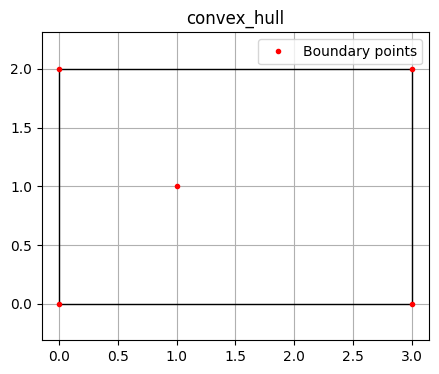

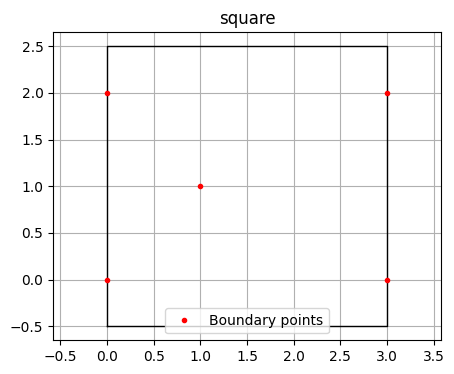

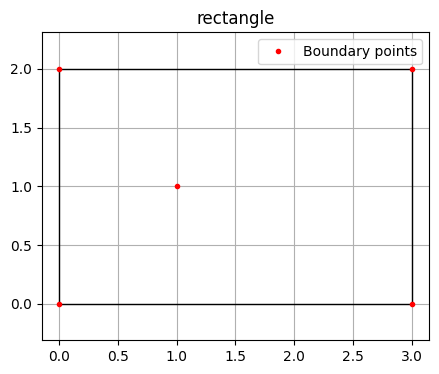

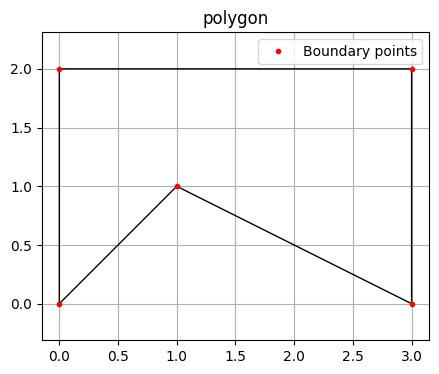

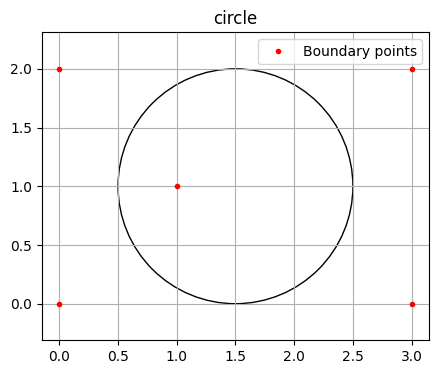

In [2]:
boundary = np.array([(0, 0), (1, 1), (3, 0), (3, 2), (0, 2)])

x = [0.5, 1.5]
y = [0.5, 1.5]

dummy_cost = CostModelComponent(
    input_keys=[],
    n_wt=2,
    cost_function=lambda: 1
)

def plot_boundary(name, constraint_comp):
    tf = TopFarmProblem(
        design_vars={'x': x, 'y': y},
        cost_comp=dummy_cost,
        constraints=[constraint_comp],
        plot_comp=XYPlotComp()
    )
    plt.figure(figsize=(5, 4))
    plt.title(name)
    tf.plot_comp.plot_constraints()
    plt.plot(boundary[:, 0], boundary[:, 1], '.r', label='Boundary points')
    plt.axis("equal")
    plt.grid(True)
    plt.legend()

plot_boundary('convex_hull', XYBoundaryConstraint(boundary, 'convex_hull'))
plot_boundary('square', XYBoundaryConstraint(boundary, 'square'))
plot_boundary('rectangle', XYBoundaryConstraint(boundary, 'rectangle'))
plot_boundary('polygon', XYBoundaryConstraint(boundary, 'polygon'))
plot_boundary('circle', CircleBoundaryConstraint((1.5, 1), 1))


### Krok 2 – Typy granic farmy

Narysowaliśmy pięć różnych typów granic: convex_hull, square, rectangle, polygon oraz circle.
Każdy typ w inny sposób aproksymuje obszar farmy wiatrowej.

Wizualnie convex_hull tworzy najmniejszą wypukłą obwiednię punktów,
polygon dokładnie odwzorowuje zadany kształt,
a square i rectangle upraszczają granicę do figur regularnych.
W praktyce wybór typu granicy wpływa na to,
jak realistycznie odwzorowujemy dostępny teren inwestycji.


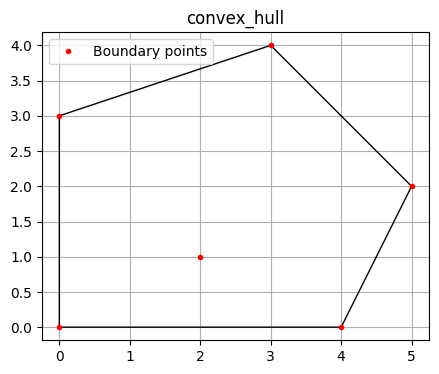

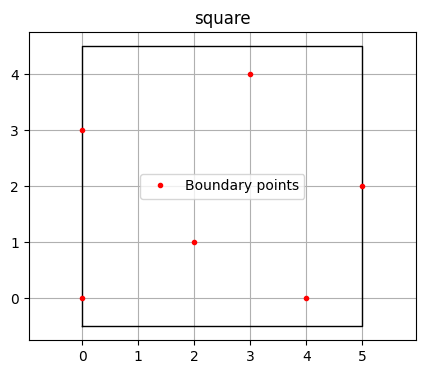

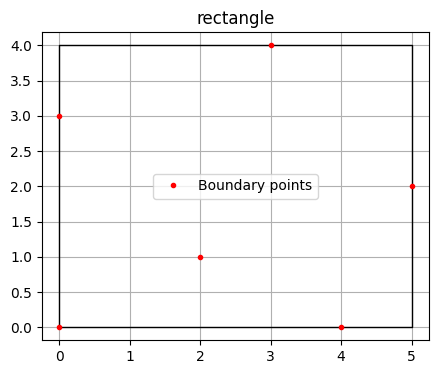

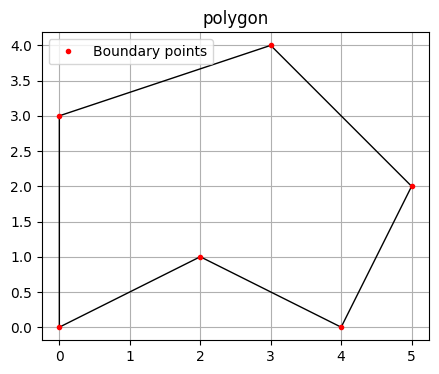

In [3]:
boundary = np.array([
    (0, 0),
    (2, 1),
    (4, 0),
    (5, 2),
    (3, 4),
    (0, 3)
])

for boundary_type in ['convex_hull', 'square', 'rectangle', 'polygon']:
    plot_boundary(boundary_type, XYBoundaryConstraint(boundary, boundary_type))


### Krok 3 – Własny obszar farmy

Zaprojektowaliśmy nieregularny obszar przypominający kształt „L”.
Porównanie convex_hull i polygon pokazuje istotną różnicę:
convex_hull „wypełnia” wklęsłości terenu,
natomiast polygon dokładnie zachowuje zaprojektowany kształt.

W praktyce polygon lepiej reprezentuje rzeczywiste granice działki,
np. wynikające z własności gruntów lub ograniczeń środowiskowych.


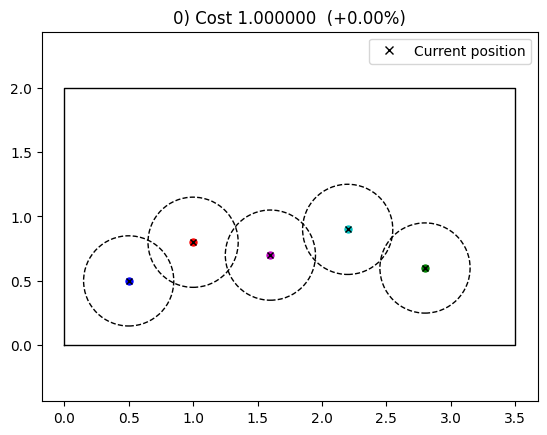

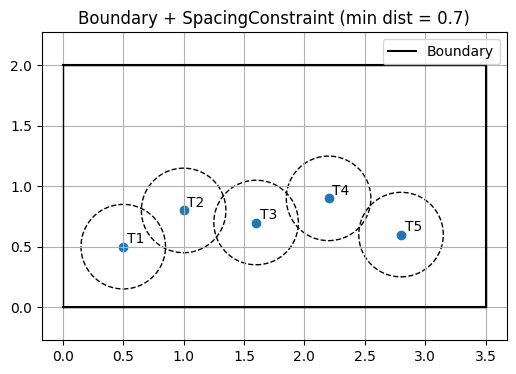

In [4]:
x5 = np.array([0.5, 1.0, 1.6, 2.2, 2.8])
y5 = np.array([0.5, 0.8, 0.7, 0.9, 0.6])

boundary_big = np.array([(0, 0), (3.5, 0), (3.5, 2), (0, 2)])

dummy_cost5 = CostModelComponent(input_keys=[], n_wt=5, cost_function=lambda: 1)

spacing = 0.7
tf = TopFarmProblem(
    design_vars={'x': x5, 'y': y5},
    cost_comp=dummy_cost5,
    constraints=[
        XYBoundaryConstraint(boundary_big, 'polygon'),
        SpacingConstraint(spacing)
    ],
    plot_comp=XYPlotComp()
)

tf.setup()
tf.evaluate()

plt.figure(figsize=(6, 4))
plt.title(f"Boundary + SpacingConstraint (min dist = {spacing})")
tf.plot_comp.plot_constraints()
plt.plot(boundary_big[:, 0], boundary_big[:, 1], '-k', label='Boundary')
plt.scatter(x5, y5)
for i, (xx, yy) in enumerate(zip(x5, y5), start=1):
    plt.text(xx + 0.03, yy + 0.03, f"T{i}")
plt.axis("equal")
plt.grid(True)
plt.legend()


### Krok 4 – Minimalna odległość między turbinami

Dodaliśmy SpacingConstraint, który wymusza minimalną odległość między turbinami.
Zmiana wartości spacing bezpośrednio wpływa na to,
czy dany układ spełnia ograniczenia.

W projektowaniu farmy wiatrowej jest to kluczowe,
ponieważ zbyt małe odległości powodują straty energetyczne
i problemy eksploatacyjne.


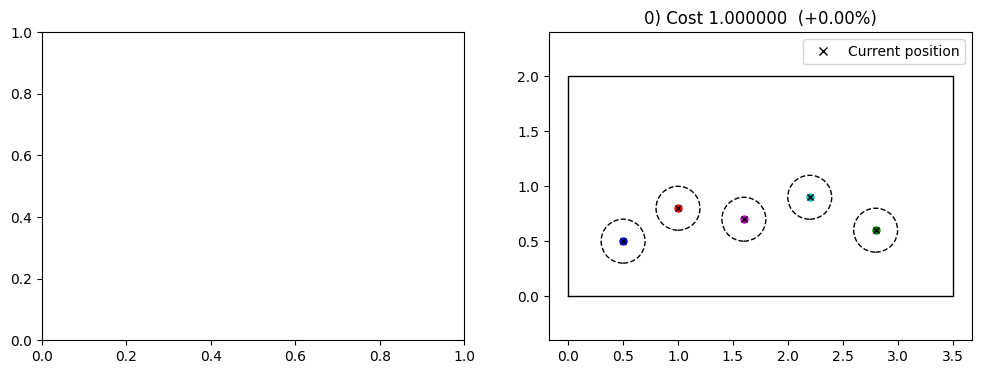

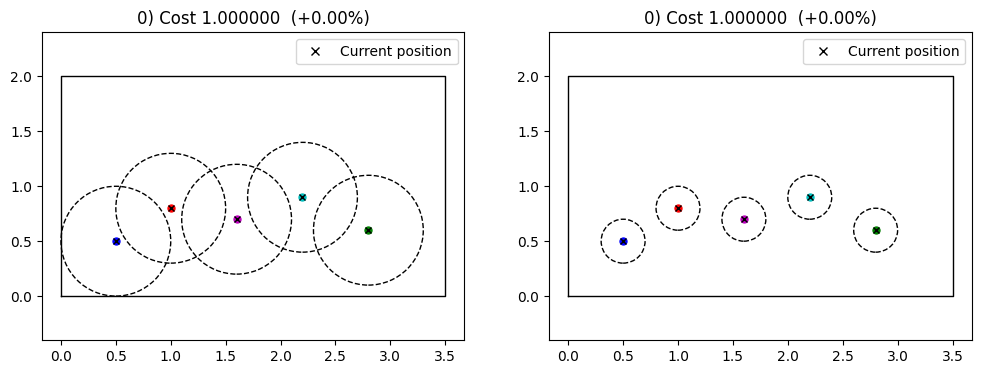

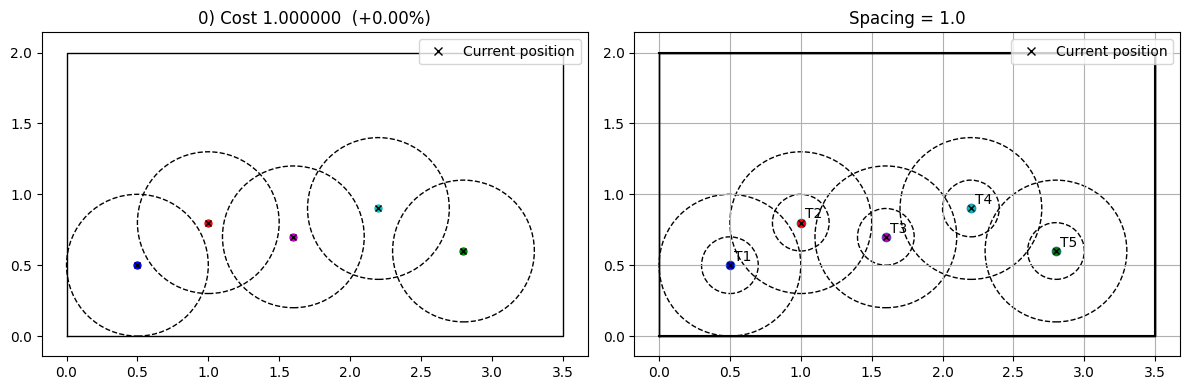

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, spacing in zip(axes, [0.4, 1.0]):
    tf = TopFarmProblem(
        design_vars={'x': x5, 'y': y5},
        cost_comp=dummy_cost5,
        constraints=[
            XYBoundaryConstraint(boundary_big, 'polygon'),
            SpacingConstraint(spacing)
        ],
        plot_comp=XYPlotComp()
    )
    tf.setup()
    tf.evaluate()

    plt.sca(ax)
    ax.set_title(f"Spacing = {spacing}")
    tf.plot_comp.plot_constraints()
    ax.plot(boundary_big[:, 0], boundary_big[:, 1], '-k')
    ax.scatter(x5, y5)
    for i, (xx, yy) in enumerate(zip(x5, y5), start=1):
        ax.text(xx + 0.03, yy + 0.03, f"T{i}")
    ax.axis("equal")
    ax.grid(True)

plt.tight_layout()


### Krok 5 – Ulepszenie wizualizacji (VibeCoding)

Z pomocą Copilota dodaliśmy jedną figurę z dwoma subplotami,
porównując spacing = 0.4 oraz spacing = 1.0.
Ułatwia to szybkie porównanie wariantów projektowych.

W praktyce takie zestawienia pomagają inżynierowi
szybko ocenić, jak zmiana jednego parametru
wpływa na spełnienie ograniczeń farmy.


### Podsumowanie lekcji

Najważniejszym wynikiem lekcji było zrozumienie,
jak w TopFarm2 połączone są design variables,
constraints, driver i problem.
Nauczyliśmy się wizualizować granice farmy
oraz minimalne odległości między turbinami.

Takie podejście odpowiada rzeczywistemu procesowi
projektowania farm wiatrowych,
gdzie najpierw analizuje się ograniczenia terenu,
a dopiero później przechodzi do optymalizacji produkcji energii.
